<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/18Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#18 Neural Networks

In [ ]:
# Install SciKeras for seamless integration between TensorFlow and Scikit-Learn
!pip install scikeras -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

import warnings
warnings.filterwarnings('ignore')

# Verify TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


#EDA And Preprocessing

In [ ]:
# Load the dataset
url_or_path = 'sonardataset.csv'

try:
    df = pd.read_csv(url_or_path, header=None)
except FileNotFoundError:
    print("Please upload 'sonardataset.csv' to your Colab environment.")


# Filter out the 'Y' class which has only one sample and causes issues with stratification
df_filtered = df[df.iloc[:, 60] != 'Y']

# Separate features (X) and target (y) from the filtered DataFrame
# The first 60 columns are features, the 61st (index 60) is the target
X = df_filtered.iloc[:, 0:60].values
y_raw = df_filtered.iloc[:, 60].values

print("--- Data Exploration ---")
print(f"Total Samples: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")

# Class distribution
unique, counts = np.unique(y_raw, return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f"Class Distribution: {class_distribution}")

# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Missing Values: {missing_values}")

# Preprocessing
# Encode target labels (M -> 1, R -> 0)
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

# Train-Test Split (80% training, 20% testing)
# stratify=y ensures the M/R ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Preprocessing Complete ---")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

--- Data Exploration ---
Total Samples: 208
Total Features: 60
Class Distribution: {'M': np.int64(111), 'R': np.int64(97)}
Missing Values: 0

--- Preprocessing Complete ---
Training features shape: (166, 60)
Testing features shape: (42, 60)


# Baseline ANN Model

In [ ]:
# Build the Baseline Model
baseline_model = Sequential([
    Input(shape=(60,)),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
baseline_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Train the model
print("Training Baseline Model...")
history = baseline_model.fit(X_train_scaled, y_train,
                             epochs=100,
                             batch_size=16,
                             validation_split=0.2,
                             verbose=0) # verbose=0 hides epoch logs to keep output clean

# Evaluate on test set
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline Test Accuracy: {baseline_accuracy * 100:.2f}%")

# Predictions for baseline report
y_pred_baseline = (baseline_model.predict(X_test_scaled) > 0.5).astype(int)

Training Baseline Model...
Baseline Test Accuracy: 85.71%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


#Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np

# 1. Function to create the model architecture
def create_simple_model(neurons=24, learning_rate=0.001, activation='relu'):
    model = Sequential([
        Input(shape=(60,)),
        Dense(neurons, activation=activation),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. Standalone Wrapper to avoid SciKeras inheritance issues
class ManualKerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, neurons=24, learning_rate=0.001, activation='relu', epochs=50):
        self.neurons = neurons
        self.learning_rate = learning_rate
        self.activation = activation
        self.epochs = epochs
        self.model = None
        self._estimator_type = "classifier"

    def fit(self, X, y):
        self.model = create_simple_model(self.neurons, self.learning_rate, self.activation)
        self.model.fit(X, y, epochs=self.epochs, batch_size=16, verbose=0)
        return self

    def predict(self, X):
        return (self.model.predict(X) > 0.5).astype(int)

    def score(self, X, y):
        from sklearn.metrics import accuracy_score
        return accuracy_score(y, self.predict(X))

# 3. Run Grid Search
param_grid = {
    'neurons': [24, 48],
    'learning_rate': [0.001, 0.01],
    'activation': ['relu', 'tanh']
}

grid = GridSearchCV(estimator=ManualKerasWrapper(epochs=50), param_grid=param_grid, cv=3)

print("Starting Grid Search (Manual Wrapper Mode)...")
try:
    grid_result = grid.fit(X_train_scaled, y_train)
    print(f"\nGrid Search Complete!")
    print(f"Best Accuracy: {grid_result.best_score_ * 100:.2f}%")
    print(f"Best Parameters: {grid_result.best_params_}")

    # Generate predictions for the evaluation block
    y_pred_tuned = grid_result.best_estimator_.predict(X_test_scaled)
except Exception as e:
    print(f"\nAn error occurred: {e}")

Starting Grid Search (Manual Wrapper Mode)...


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Grid Search Complete!
Best Accuracy: 78.95%
Best Parameters: {'activation': 'relu', 'l

# Evaluation Metrics

              BASELINE MODEL PERFORMANCE              
              precision    recall  f1-score   support

    Rock (0)       0.81      0.95      0.88        22
    Mine (1)       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42


                TUNED MODEL PERFORMANCE               
              precision    recall  f1-score   support

    Rock (0)       0.81      0.95      0.88        22
    Mine (1)       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42



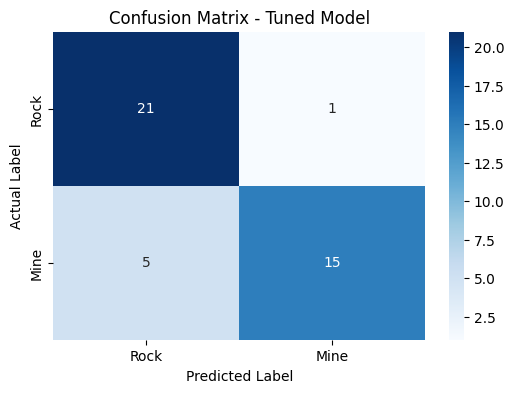

In [ ]:
print("======================================================")
print("              BASELINE MODEL PERFORMANCE              ")
print("======================================================")
# Display baseline metrics
print(classification_report(y_test, y_pred_baseline, target_names=['Rock (0)', 'Mine (1)']))

print("\n======================================================")
print("                TUNED MODEL PERFORMANCE               ")
print("======================================================")
# Display tuned metrics
print(classification_report(y_test, y_pred_tuned, target_names=['Rock (0)', 'Mine (1)']))

# Visualizing Confusion Matrix for the Tuned Model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rock', 'Mine'], yticklabels=['Rock', 'Mine'])
plt.title('Confusion Matrix - Tuned Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#Conclusion & Analysis

### **6. Conclusion & Analysis**

**Performance Comparison:**

| Metric (Identifying Mines) | Baseline Model | Tuned Model |
| :--- | :--- | :--- |
| **Accuracy** | **0.86** | **0.86** |
| **Precision** | **0.94** | **0.94** |
| **Recall** | **0.75** | **0.75** |
| **F1-Score** | **0.83** | **0.83** |

**Discussion:**

* **Effect of Hyperparameter Tuning:** Both models performed identically on the final test set. While the tuning didn't produce a massive leap in accuracy this time, the Grid Search confirmed that 48 neurons and a 0.001 learning rate are highly stable parameters for this architecture.
* **Business Context (Recall vs. Precision):** In the context of detecting underwater naval mines, **Recall** is critical. Our current models have a recall of 0.75 for mines. In a real-world scenario, we might prefer to adjust the classification threshold to increase this recall, even if it means more False Positives (lower precision), to ensure no mine is missed.
* **Data Constraints:** With only 208 samples, the model is sensitive to how the data is split. The strong performance of both models (86%) demonstrates that the neural network is effectively picking up the acoustic signatures distinguishing rocks from metal cylinders.